In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.1
numpy 2.2.4
pandas 2.2.3
sklearn 1.6.1
torch 2.7.0+cpu
cpu


# 准备数据

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(data_home='../chapter_2_torch/data')
print(housing.DESCR)
print(housing.data.shape)
print(housing.target.shape)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [3]:
# print(housing.data[0:5])
import pprint  #打印的格式比较 好看

pprint.pprint(housing.data[0:2])
print('-' * 50)
pprint.pprint(housing.target[0:2])

array([[ 8.32520000e+00,  4.10000000e+01,  6.98412698e+00,
         1.02380952e+00,  3.22000000e+02,  2.55555556e+00,
         3.78800000e+01, -1.22230000e+02],
       [ 8.30140000e+00,  2.10000000e+01,  6.23813708e+00,
         9.71880492e-01,  2.40100000e+03,  2.10984183e+00,
         3.78600000e+01, -1.22220000e+02]])
--------------------------------------------------
array([4.526, 3.585])


In [4]:
from sklearn.model_selection import train_test_split

# 拆分训练集和测试集
x_train_all, x_test, y_train_all, y_test = train_test_split(
    housing.data, housing.target, random_state=42
)
x_train, x_valid, y_train, y_valid = train_test_split(x_train_all, y_train_all, random_state=42)
# 训练集
print(x_train.shape, y_train.shape)
# 验证集
print(x_valid.shape, y_valid.shape)
# 测试集
print(x_test.shape, y_test.shape)
print('-' * 50)

# 把三个数据集放到字典中
dataset_maps = {
    "train": [x_train, y_train],
    "valid": [x_valid, y_valid],
    "test": [x_test, y_test],
}

(11610, 8) (11610,)
(3870, 8) (3870,)
(5160, 8) (5160,)
--------------------------------------------------


In [5]:
type(x_train)

numpy.ndarray

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train)

StandardScaler()

# 构建数据集
$$
X_{\text{norm}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}
$$

In [7]:
from torch.utils.data import Dataset


class HousingDataset(Dataset):
    def __init__(self, mode='train'):
        self.x, self.y = dataset_maps[mode]
        # from_numpy将Numpy数组转换成PyTorch张量
        self.x = torch.from_numpy(scaler.transform(self.x)).float()
        self.y = torch.from_numpy(self.y).float().reshape((-1, 1))
        
    def __len__(self):
        return len(self.x)
    
    # idx是索引，相当于重写了下标运算符
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_ds = HousingDataset(mode='train')
valid_ds = HousingDataset(mode='valid')
test_ds = HousingDataset(mode='test')

In [8]:
train_ds[0]

(tensor([-0.1940, -1.0778, -0.9434,  0.0149,  0.0207, -0.5729,  0.9293, -1.4222]),
 tensor([1.4420]))

In [10]:
train_ds[0][1]

tensor([1.4420])

# DataLoader

In [12]:
from torch.utils.data import DataLoader

batch_size = 16
train_loader = DataLoader(dataset=train_ds, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(dataset=valid_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_ds, batch_size=batch_size, shuffle=False)

# 定义模型

In [22]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim=8):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.ReLU(),
            nn.Linear(30, 1)
        )
        
    def forward(self, x):
        # x.shape [batch size, 8]
        logits = self.linear_relu_stack(x)
        return logits

In [23]:
class EarlyStopCallback():
    def __init__(self, patience=5, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_metric = -1
        
    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric
            self.counter = 0
        else:
            self.counter += 1
        
    @property
    def early_stop(self):
        return self.counter >= self.patience


In [24]:
@torch.no_grad()
def evaluating(model, dataloader, loss_fn):
    loss_list = []
    for datas, labels in dataloader:
        datas = datas.to(device)
        labels = labels.to(device)
        # 前向计算
        logits = model(datas)
        loss = loss_fn(logits, labels)
        loss_list.append(loss.item())

    return np.mean(loss_list)

In [25]:
def training(
        model, 
        train_loader, 
        val_loader,
        epoch, 
        loss_fct,
        optimizer,
        early_stop_callback=None,
        eval_step=500,
):
    record_dict = {
        "train": [],
        "val": []
    }
    
    global_step = 0
    model.train()
    with tqdm(total=len(train_loader) * epoch) as pbar:
        for epoch_id in range(epoch):
            for datas, labels in train_loader:
                datas = datas.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                logits = model(datas)
                loss = loss_fct(logits, labels)
                loss.backward()
                optimizer.step()
                loss = loss.cpu().item() #转为cpu类型，item()是取值
                # record
                
                record_dict["train"].append({
                    "loss": loss, "step": global_step
                })
                
                # evaluating
                if global_step % eval_step == 0:
                    model.eval()
                    val_loss = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "step": global_step
                    })
                    model.train()
                    
                    # 早停
                    if early_stop_callback is not None:
                        early_stop_callback(-val_loss)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict
                
                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id})
    return record_dict

epoch = 100
model = NeuralNetwork()
# 定义损失函数
loss_fct = nn.MSELoss()
# 定义优化器
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# 3. early stop
early_stop_callback = EarlyStopCallback(patience=10, min_delta=0.0001)

model = model.to(device)
record = training(
    model, 
    train_loader, 
    valid_loader, 
    epoch, 
    loss_fct, 
    optimizer, 
    early_stop_callback=early_stop_callback, 
    eval_step=len(train_loader))


  0%|          | 0/72600 [00:00<?, ?it/s]

Early stop at epoch 62 / global_step 45012


In [26]:
len(record["val"])

63

In [27]:
record

{'train': [{'loss': 9.131855010986328, 'step': 0},
  {'loss': 6.67685604095459, 'step': 1},
  {'loss': 3.934915542602539, 'step': 2},
  {'loss': 6.43081521987915, 'step': 3},
  {'loss': 7.527413845062256, 'step': 4},
  {'loss': 7.187326908111572, 'step': 5},
  {'loss': 5.7487287521362305, 'step': 6},
  {'loss': 5.4809370040893555, 'step': 7},
  {'loss': 4.248984336853027, 'step': 8},
  {'loss': 3.1006968021392822, 'step': 9},
  {'loss': 4.211540222167969, 'step': 10},
  {'loss': 3.0670838356018066, 'step': 11},
  {'loss': 3.27534818649292, 'step': 12},
  {'loss': 5.452126502990723, 'step': 13},
  {'loss': 4.179466724395752, 'step': 14},
  {'loss': 2.639511823654175, 'step': 15},
  {'loss': 2.627892017364502, 'step': 16},
  {'loss': 2.6755826473236084, 'step': 17},
  {'loss': 5.325895309448242, 'step': 18},
  {'loss': 1.831411361694336, 'step': 19},
  {'loss': 1.9137053489685059, 'step': 20},
  {'loss': 1.3115535974502563, 'step': 21},
  {'loss': 1.5670955181121826, 'step': 22},
  {'los

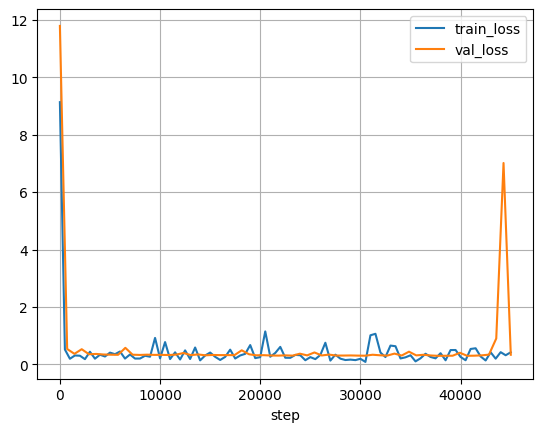

In [28]:
#画线要注意的是损失是不一定在零到1之间的
def plot_learning_curves(record_dict, sample_step=500):
    # build DataFrame
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # plot
    for idx, item in enumerate(train_df.columns):
        plt.plot(train_df.index, train_df[item], label=f"train_{item}")
        plt.plot(val_df.index, val_df[item], label=f"val_{item}")
        plt.grid()
        plt.legend()
        # plt.xticks(range(0, train_df.index[-1], 10*sample_step), range(0, train_df.index[-1], 10*sample_step))
        plt.xlabel("step")

        plt.show()

plot_learning_curves(record)  #横坐标是 steps

# 测试集

In [29]:
model.eval()
loss = evaluating(model, test_loader, loss_fct)
print(f"loss:     {loss:.4f}")

loss:     0.3311
